In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\dell\Downloads\used_car_price_prediction_1M.csv")

In [3]:
df

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06
1004996,Honda,Amaze,2005,NaN,1705.773023,99.643689,CNG,Automatic,First,NaN,Pune,311400,1,1,0,1,4,5,20,7.122346e+05
1004997,Skoda,Octavia,2018,21.665335,1447.159515,NaN,Petrol,NaN,First,Brown,Delhi,42140,0,1,0,1,4,4,7,1.304198e+06
1004998,BMW,X3,2010,17.852635,2179.906631,NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,1.866610e+06


In [4]:
df.columns

Index(['Brand', 'Model', 'Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City',
       'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents',
       'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  object 
 1   Model             1005000 non-null  object 
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         926267 non-null   object 
 7   Transmission      924615 non-null   object 
 8   Owner_Type        1005000 non-null  object 
 9   Color             924581 non-null   object 
 10  City              924570 non-null   object 
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  

In [6]:
df.isnull().sum()

Brand                   0
Model                   0
Year                    0
Mileage_kmpl        80390
Engine_CC           80403
Horsepower          80403
Fuel_Type           78733
Transmission        80385
Owner_Type              0
Color               80419
City                80430
Kms_Driven              0
Insurance_Valid         0
Service_History         0
Accidents               0
Tax_Paid                0
Number_of_Doors         0
Seats                   0
Registration_Age        0
Price                   0
dtype: int64

In [7]:
# ans=df.dropna(axis=0)
# ans.isnull().sum()

In [8]:
(df.isnull().sum() / len(df)) * 100

Brand               0.000000
Model               0.000000
Year                0.000000
Mileage_kmpl        7.999005
Engine_CC           8.000299
Horsepower          8.000299
Fuel_Type           7.834129
Transmission        7.998507
Owner_Type          0.000000
Color               8.001891
City                8.002985
Kms_Driven          0.000000
Insurance_Valid     0.000000
Service_History     0.000000
Accidents           0.000000
Tax_Paid            0.000000
Number_of_Doors     0.000000
Seats               0.000000
Registration_Age    0.000000
Price               0.000000
dtype: float64

In [9]:
Q1 = df['Price'].quantile(0.25) 
Q3 = df['Price'].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
print("Number of outliers:", len(outliers))
print(outliers[['Brand', 'Model', 'Price']].head(20))

Number of outliers: 70413
        Brand     Model         Price
3         BMW        X1  2.949453e+06
10   Mercedes   E-Class  4.032569e+06
24        BMW  3 Series  3.246262e+06
37       Audi        Q5  3.151376e+06
73       Audi        A4  2.962194e+06
94       Audi        Q3  2.989961e+06
114  Mercedes       GLA  3.170500e+06
124       BMW  3 Series  2.952209e+06
126  Mercedes   E-Class  3.722875e+06
131       BMW  3 Series  3.521516e+06
152  Mercedes   C-Class  4.157704e+06
175  Mercedes   E-Class  2.976379e+06
202  Mercedes       GLA  3.305183e+06
216       BMW  3 Series  3.054107e+06
234       BMW  3 Series  3.533215e+06
247      Audi        A4  2.996254e+06
254       Kia    Carens  4.816404e+06
275       BMW  3 Series  3.465306e+06
295  Mercedes   C-Class  3.638751e+06
302  Mercedes   C-Class  3.134833e+06


Number of outliers: 9948


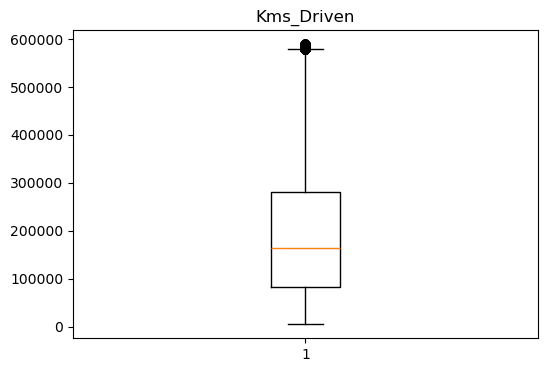

In [10]:
Q1 = df['Kms_Driven'].quantile(0.25)
Q3 = df['Kms_Driven'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Kms_Driven'] < lower) | (df['Kms_Driven'] > upper)]
df = df[(df['Kms_Driven'] >= lower) & (df['Kms_Driven'] <= upper)]
print("Number of outliers:", len(outliers))
# print(outliers[['Brand', 'Model', 'Kms_Driven']].head(20))

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.boxplot(df['Kms_Driven'])
plt.title("Kms_Driven")
plt.show()

Number of outliers: 3962


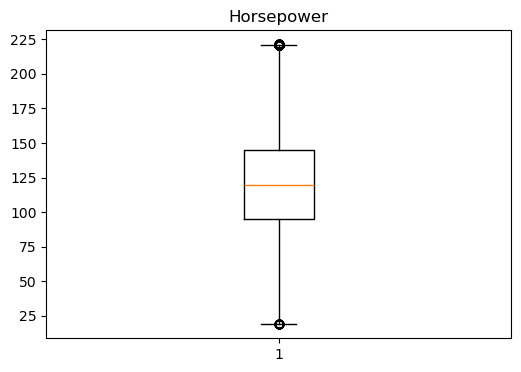

In [11]:
Q1 = df['Horsepower'].quantile(0.25)
Q3 = df['Horsepower'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Horsepower'] < lower) | (df['Horsepower'] > upper)]
df = df[(df['Horsepower'] >= lower) & (df['Horsepower'] <= upper)]
print("Number of outliers:", len(outliers))

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.boxplot(df['Horsepower'])
plt.title("Horsepower")
plt.show()

Number of outliers: 5882


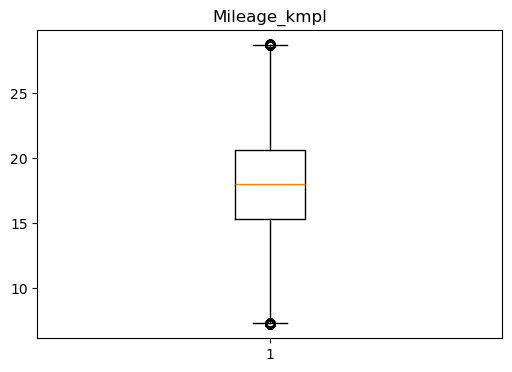

In [12]:
Q1 = df['Mileage_kmpl'].quantile(0.25)
Q3 = df['Mileage_kmpl'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Mileage_kmpl'] < lower) | (df['Mileage_kmpl'] > upper)]
df = df[(df['Mileage_kmpl'] >= lower) & (df['Mileage_kmpl'] <= upper)]
print("Number of outliers:", len(outliers))

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.boxplot(df['Mileage_kmpl'])
plt.title("Mileage_kmpl")
plt.show()

Number of outliers: 1705


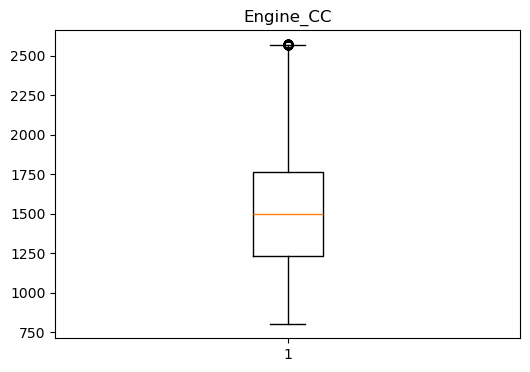

In [13]:
Q1 = df['Engine_CC'].quantile(0.25)
Q3 = df['Engine_CC'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Engine_CC'] < lower) | (df['Engine_CC'] > upper)]
df = df[(df['Engine_CC'] >= lower) & (df['Engine_CC'] <= upper)]
print("Number of outliers:", len(outliers))

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.boxplot(df['Engine_CC'])
plt.title("Engine_CC")
plt.show()

In [14]:
print(df['Kms_Driven'].describe())

count    764247.000000
mean     193939.168514
std      136392.298566
min        5000.000000
25%       83733.000000
50%      164568.000000
75%      281680.000000
max      589104.000000
Name: Kms_Driven, dtype: float64


In [15]:
#df = df[df['Kms_Driven'] <= 500000]

In [16]:
df['Mileage_kmpl'] = df['Mileage_kmpl'].fillna(df['Mileage_kmpl'].median())

In [17]:
df['Engine_CC'] = df['Engine_CC'].fillna(df['Engine_CC'].median())

In [18]:
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())

In [19]:
df['Fuel_Type'].unique()

array(['Petrol', nan, 'Diesel', 'Hybrid', 'CNG', 'Electric', 'electrik',
       ' Diesel', 'PETROL', 'petrol', 'hybridd', 'diesel '], dtype=object)

In [20]:
df['Fuel_Type'] = df['Fuel_Type'].replace({ 'hybridd': 'Hybrid' })

In [21]:
df['Fuel_Type'] = df['Fuel_Type'].replace({ 'electrik': 'Electric' })

In [22]:
df['Fuel_Type'] = df['Fuel_Type'].replace( ['petrol','PETROL'],'Petrol' )

In [23]:

df['Fuel_Type'] = df['Fuel_Type'].str.replace(r'\s*diesel\s*', 'Diesel', case=False, regex=True)

In [24]:
df['Fuel_Type'].unique()

array(['Petrol', nan, 'Diesel', 'Hybrid', 'CNG', 'Electric'], dtype=object)

In [25]:
df['Fuel_Type'] = df['Fuel_Type'].fillna(df['Fuel_Type'].mode()[0])

In [26]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'CNG', 'Electric'], dtype=object)

In [27]:
df['Transmission'].value_counts()

Transmission
Manual       456263
Automatic    246607
Name: count, dtype: int64

In [28]:
df['Transmission'] = df['Transmission'].fillna(df['Transmission'].mode()[0])

In [29]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [30]:
df['Color'].unique()

array(['Grey', 'Black', 'White', nan, 'Blue', 'Brown', 'Silver', 'Red'],
      dtype=object)

In [31]:
df['Color'] = df['Color'].fillna(df['Color'].mode()[0])

In [32]:
df['City'].unique()

array(['Mumbai', 'Kolkata', 'Chennai', 'Hyderabad', 'Pune', 'Delhi',
       'Ahmedabad', 'Bangalore', nan], dtype=object)

In [33]:
df['City'] = df['City'].fillna(df['City'].mode()[0])

In [34]:
df['City'].unique()

array(['Mumbai', 'Kolkata', 'Chennai', 'Hyderabad', 'Pune', 'Delhi',
       'Ahmedabad', 'Bangalore'], dtype=object)

In [35]:
df.isnull().sum()

Brand               0
Model               0
Year                0
Mileage_kmpl        0
Engine_CC           0
Horsepower          0
Fuel_Type           0
Transmission        0
Owner_Type          0
Color               0
City                0
Kms_Driven          0
Insurance_Valid     0
Service_History     0
Accidents           0
Tax_Paid            0
Number_of_Doors     0
Seats               0
Registration_Age    0
Price               0
dtype: int64

In [36]:
df.dtypes

Brand                object
Model                object
Year                  int64
Mileage_kmpl        float64
Engine_CC           float64
Horsepower          float64
Fuel_Type            object
Transmission         object
Owner_Type           object
Color                object
City                 object
Kms_Driven            int64
Insurance_Valid       int64
Service_History       int64
Accidents             int64
Tax_Paid              int64
Number_of_Doors       int64
Seats                 int64
Registration_Age      int64
Price               float64
dtype: object

In [37]:

df.rename({'Accidents':'Num_of_Accidents','Seats':'Number_of_Seats'},axis=1,inplace=True)

In [38]:
df = df.astype({'Insurance_Valid': 'boolean'})

In [39]:
df.dtypes

Brand                object
Model                object
Year                  int64
Mileage_kmpl        float64
Engine_CC           float64
Horsepower          float64
Fuel_Type            object
Transmission         object
Owner_Type           object
Color                object
City                 object
Kms_Driven            int64
Insurance_Valid     boolean
Service_History       int64
Num_of_Accidents      int64
Tax_Paid              int64
Number_of_Doors       int64
Number_of_Seats       int64
Registration_Age      int64
Price               float64
dtype: object

In [40]:
df['Brand'].unique()

array(['Hyundai', 'Mahindra', 'Honda', 'Volkswagen', 'Audi', 'Mercedes',
       'Kia', 'Ford', 'Nissan', 'Tata', 'Toyota', 'BMW', 'Skoda', ' BMW ',
       ' Kia ', ' Ford ', ' Volkswagen ', ' Tata ', ' Skoda ', ' Honda ',
       ' Nissan ', ' Hyundai ', ' Audi ', ' Mercedes ', ' Toyota ',
       ' Mahindra '], dtype=object)

In [41]:
print(df.duplicated().sum())

3812


In [42]:
df.drop_duplicates(inplace=True)

In [43]:
print(df.duplicated().sum())

0


In [44]:
df['Brand'] = df['Brand'].str.strip()

In [45]:
df['Brand'].unique()

array(['Hyundai', 'Mahindra', 'Honda', 'Volkswagen', 'Audi', 'Mercedes',
       'Kia', 'Ford', 'Nissan', 'Tata', 'Toyota', 'BMW', 'Skoda'],
      dtype=object)

In [46]:
text_columns = ['Brand', 'Model', 'Fuel_Type', 'Transmission',
                'Owner_Type', 'Color', 'City']
for col in text_columns:
    df[col] = df[col].str.strip()

In [47]:
df['Owner_Type'].unique()

array(['First', 'Second', 'Fourth+', 'Third'], dtype=object)

In [48]:
owner_map = {
    'First':1,
    'Second':2,
    'Third':3,
    'Fourth+':4
}

In [49]:
df['Owner_Type'] = df['Owner_Type'].map(owner_map)

In [50]:
import sklearn

In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Transmission'] = le.fit_transform(df['Transmission'])

In [52]:
df = pd.get_dummies(df,columns=['Brand','Model','Fuel_Type','Color','City'], drop_first = True)

In [53]:
df.dtypes.unique()

array([dtype('int64'), dtype('float64'), BooleanDtype, dtype('bool')],
      dtype=object)

In [54]:
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns

df[bool_cols] = df[bool_cols].astype(int)

In [55]:
df.dtypes.unique()

array([dtype('int64'), dtype('float64')], dtype=object)

In [56]:
df

,Year,Mileage_kmpl,Engine_CC,Horsepower,Transmission,Owner_Type,Kms_Driven,Insurance_Valid,Service_History,Num_of_Accidents,...,Color_Red,Color_Silver,Color_White,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune
1,2012,19.478608,1130.771005,137.021719,1,1,211510,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,2008,17.469920,1766.466250,142.902960,0,1,333999,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2022,18.326833,1239.334935,121.505993,1,2,43404,1,0,0,...,0,0,1,0,0,0,0,1,0,0
6,2014,16.328654,1398.722600,111.846497,1,1,200343,1,0,0,...,0,0,0,0,1,0,0,0,0,0
8,2020,17.461847,1397.891768,104.095168,0,4,122025,1,1,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004987,2024,23.306683,1234.641151,92.856287,1,3,7261,1,0,0,...,0,1,0,0,0,0,1,0,0,0
1004988,2020,8.097582,1641.225144,118.952121,1,1,50155,1,0,1,...,0,0,0,0,0,0,0,0,0,1
1004990,2008,13.935683,1287.775569,114.498130,1,1,269892,1,1,0,...,1,0,0,0,0,0,1,0,0,0
1004991,2003,19.946978,1252.293439,115.394192,1,1,533082,1,1,0,...,0,0,0,1,0,0,0,0,0,0


In [57]:
df['Price']

1          9.596943e+05
2          2.920229e+05
4          6.365208e+05
6          4.953191e+05
8          1.045347e+06
               ...     
1004987    8.436442e+05
1004988    8.224758e+05
1004990    3.963039e+05
1004991    5.000000e+04
1004995    1.104233e+06
Name: Price, Length: 760435, dtype: float64

In [58]:
df['Price']=df['Price'].astype(int)
df['Price'].dtype
pd.set_option('display.float_format','{:.2f}'.format)


In [59]:
df['Price']

1           959694
2           292022
4           636520
6           495319
8          1045347
            ...   
1004987     843644
1004988     822475
1004990     396303
1004991      50000
1004995    1104233
Name: Price, Length: 760435, dtype: int64

In [60]:
X = df.drop('Price', axis=1)
y = df['Price']

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.preprocessing import StandardScaler
# X = df.drop('Price', axis=1)
# y = df['Price']

num_cols = [
    'Year',
    'Mileage_kmpl',
    'Engine_CC',
    'Horsepower',
    'Kms_Driven',
    'Registration_Age'
]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (608348, 81)
Testing Features  : (152087, 81)
Training Target   : (608348,)
Testing Target    : (152087,)


In [64]:
print(X_train[num_cols].mean())
print(X_train[num_cols].std())

Year                0.00
Mileage_kmpl        0.00
Engine_CC           0.00
Horsepower         -0.00
Kms_Driven          0.00
Registration_Age   -0.00
dtype: float64
Year               1.00
Mileage_kmpl       1.00
Engine_CC          1.00
Horsepower         1.00
Kms_Driven         1.00
Registration_Age   1.00
dtype: float64


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [66]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_train, y_train) * 100, lr.score(X_test, y_test) * 100

(54.45766230393426, 54.59769486961284)

In [67]:
lasso = Lasso(alpha=0.05, max_iter=1000, tol=0.1, selection="random")
lasso.fit(X_train, y_train)
lasso.score(X_train, y_train) * 100, lasso.score(X_test, y_test) * 100

(54.45766230355746, 54.59769489347144)

In [68]:
ridge = Ridge(alpha=5)
ridge.fit(X_train, y_train)
ridge.score(X_train, y_train) * 100, ridge.score(X_test, y_test) * 100

(54.457661346719256, 54.59769087338986)

In [69]:
en = ElasticNet(alpha=0.01)
en.fit(X_train, y_train)
en.score(X_train, y_train) * 100, en.score(X_test, y_test) * 100

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.357e+17, tolerance: 6.413e+13
  model = cd_fast.enet_coordinate_descent(


(54.20039448392047, 54.33848153939922)

In [70]:
dt1 = DecisionTreeRegressor()
dt1.fit(X_train, y_train)
dt1.score(X_train, y_train) * 100, dt1.score(X_test, y_test) * 100

(100.0, 43.09813854166457)

In [71]:
dt = DecisionTreeRegressor(max_depth=10,min_samples_leaf=20,min_samples_split=50, random_state=42,)
dt.fit(X_train, y_train)
dt.score(X_train, y_train) * 100, dt.score(X_test, y_test) * 100

(69.01867785518304, 66.32704874223548)

In [72]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,max_depth=12,min_samples_leaf=10,n_jobs=-1,random_state=42,)
rf.fit(X_train, y_train)
rf.score(X_train, y_train) * 100, rf.score(X_test, y_test) * 100

(72.79687507443637, 68.79651584397185)

In [ ]:
adaboost = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)
adaboost.fit(X_train, y_train)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [73]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbr = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr.score(X_train, y_train) * 100, gbr.score(X_test, y_test) * 100

C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

(73.74555106919736, 69.8148048712212)

In [74]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gbr,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=1
)

print("5-Fold CV R² Scores:")
print(cv_scores)

print("\nAverage CV R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold CV R² Scores:
[0.69787538 0.71505134 0.70656107 0.69880704 0.70681311]

Average CV R²: 0.705021585712824
Standard Deviation: 0.0062588246519215875


In [75]:
# from sklearn.ensemble import RandomForestRegressor
# rf = RandomForestRegressor(n_estimators=100,max_depth=12,min_samples_leaf=10,n_jobs=1,random_state=42,)
# rf.fit(X_train, y_train)
# rf.score(X_train, y_train) * 100, rf.score(X_test, y_test) * 100

In [76]:
# from sklearn.ensemble import RandomForestRegressor
# rf = RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_leaf=10,n_jobs=1,random_state=42,)
# rf.fit(X_train, y_train)
# rf.score(X_train, y_train) * 100, rf.score(X_test, y_test) * 100

In [77]:

y_predict = rf.predict(X_test)

In [78]:

y_predict

array([ 219846.48620765,  412814.43128622, 2297660.40402972, ...,
       2719501.64378452,  109626.48389857,  711079.30187835])

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print("MAE :", mae)
print(f"MSE : {mse:.2f}")
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 346856.54010792
MSE : 327654305655.22
RMSE: 572410.9587134207
R² Score: 0.6879651584397185


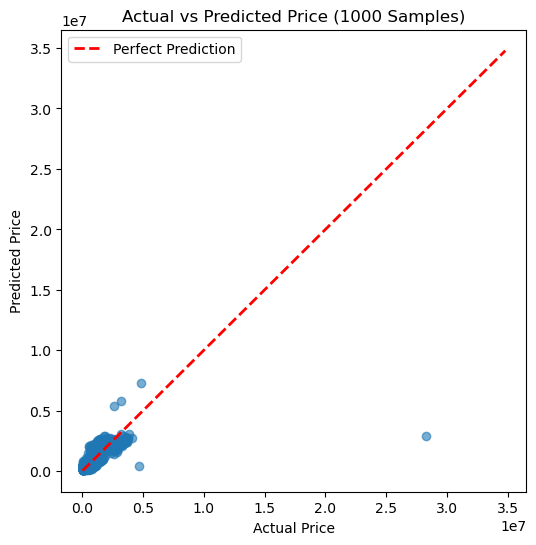

In [80]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test.iloc[:1000],
    y_predict[:1000],
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (1000 Samples)")
plt.legend()

plt.show()

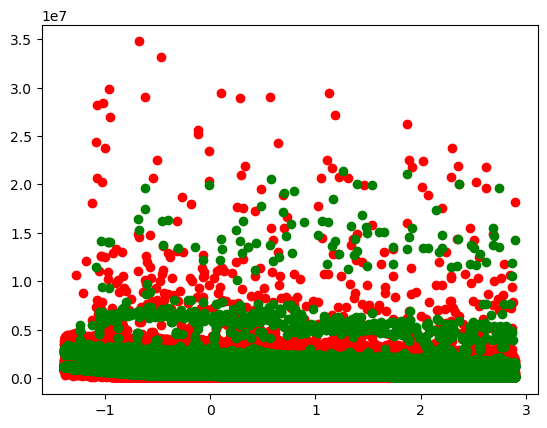

In [81]:
plt.scatter(X_test['Kms_Driven'],y_test,c="r") #Actual point
plt.scatter(X_test['Kms_Driven'],y_predict,c="g") #Predicted point

In [82]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_predict
})

comparison.head(10)

,Actual Price,Predicted Price
0,50000,219846.49
1,284210,412814.43
2,3336169,2297660.40
3,247365,479767.67
4,3508635,2524141.34
5,751902,833963.64
6,687790,1002297.56
7,1139492,1706277.35
8,649504,990622.92
9,374877,717486.84


In [83]:
# coef_df = pd.DataFrame({
#     "Feature": X_train.columns,
#     "Coefficient": model.coef_
# })

# print(coef_df.sort_values(by="Coefficient", key=abs, ascending=False).head(20))
# print("Intercept :",model.intercept_)


importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

print(
    importance_df
    .sort_values(by="Importance", ascending=False)
    .head(20)
)

             Feature  Importance
20    Brand_Mercedes        0.23
6         Kms_Driven        0.22
14         Brand_BMW        0.18
0               Year        0.08
13  Registration_Age        0.07
49          Model_Q3        0.07
50          Model_Q5        0.06
26          Model_A4        0.06
3         Horsepower        0.01
2          Engine_CC        0.01
1       Mileage_kmpl        0.00
25  Brand_Volkswagen        0.00
18         Brand_Kia        0.00
22       Brand_Skoda        0.00
5         Owner_Type        0.00
9   Num_of_Accidents        0.00
67  Fuel_Type_Petrol        0.00
11   Number_of_Doors        0.00
4       Transmission        0.00
8    Service_History        0.00


In [84]:
import joblib

joblib.dump(rf, "carPrice.pkl")

['carPrice.pkl']

In [85]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.base import clone
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV

# print("Training shape:", X_train.shape)
# print("Testing shape :", X_test.shape)

In [86]:
# def evaluate_regression_model(name, model):
#     model.fit(X_train, y_train)
#     train_pred = model.predict(X_train)
#     test_pred = model.predict(X_test)

#     rss = np.sum((y_test.values - test_pred) ** 2)
#     mse = mean_squared_error(y_test, test_pred)
#     rmse = np.sqrt(mse)
#     r2 = r2_score(y_test, test_pred)
#     mae = mean_absolute_error(y_test, test_pred)
#     train_r2 = r2_score(y_train, train_pred)

#     return {
#         "Model": name,
#         "RSS": rss,
#         "RMSE": rmse,
#         "R²": r2,
#         "MAE": mae,
#         "Train R²": train_r2,
#         "Test R²": r2,
#         "Gap": train_r2 - r2,
#     }, model

In [87]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge Regression": Ridge(alpha=5),
#     "Lasso Regression": Lasso(alpha=0.05, max_iter=2000, tol=0.1, selection="random", random_state=42),
#     "Decision Tree": DecisionTreeRegressor(random_state=42),
#     "Random Forest": RandomForestRegressor(
#         n_estimators=100, max_depth=12, min_samples_leaf=10,
#         n_jobs=-1, random_state=42
#     ),
#     "AdaBoost": AdaBoostRegressor(
#         n_estimators=100, learning_rate=0.05, random_state=42
#     ),
#     "Gradient Boosting": GradientBoostingRegressor(
#         n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42
#     ),
# }

# results = []
# fitted_models = {}

# for name, estimator in models.items():
#     print(f"Training: {name}")
#     row, fitted = evaluate_regression_model(name, estimator)
#     results.append(row)
#     fitted_models[name] = fitted

# results_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
# results_df

In [88]:
# comparison_table = results_df[["Model", "RSS", "RMSE", "R²"]].copy()
# comparison_table

In [89]:
import os, json, joblib, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = os.getcwd()
OUT = os.path.join(ROOT, "model_artifacts")
os.makedirs(OUT, exist_ok=True)


# Calculate model metrics
def metric_record(display_name, estimator):
    yp_train = estimator.predict(X_train)
    yp_test = estimator.predict(X_test)

    return {
        "display_name": display_name,

        # Train
        "train_r2": float(r2_score(y_train, yp_train)),

        # Test
        "test_r2": float(r2_score(y_test, yp_test)),
        "mae": float(mean_absolute_error(y_test, yp_test)),
        "rmse": float(np.sqrt(mean_squared_error(y_test, yp_test))),

        # RSS
        "rss": float(np.sum((y_test - yp_test) ** 2)),
    }


# All models trained in the notebook
models = {
    "Linear Regression": lr,
    "Lasso": lasso,
    "Ridge": ridge,
    "ElasticNet": en,
    "Decision Tree (Tuned)": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
}


# Create registry
registry = {
    name: metric_record(name, est)
    for name, est in models.items()
}


# Save Gradient Boosting as the deployed model
joblib.dump(gbr, os.path.join(OUT, "carPrice.pkl"))


# Save preprocessing information
artifacts = {
    "feature_names": list(X_train.columns),
    "scaler": scaler,
    "num_cols": list(num_cols),
    "transmission_encoder": le,
}

joblib.dump(
    artifacts,
    os.path.join(OUT, "preprocessing_artifacts.pkl")
)


# Save all models
joblib.dump(
    models,
    os.path.join(OUT, "models.pkl")
)


# Save model metrics
joblib.dump(
    registry,
    os.path.join(OUT, "model_registry.pkl")
)


# Save run information
with open(
    os.path.join(OUT, "run_info.json"),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "source_notebook": "MLProject(3).ipynb",
            "feature_count": len(X_train.columns),
            "deployed_model": "Gradient Boosting",
            "train_rows": int(len(X_train)),
            "test_rows": int(len(X_test)),
        },
        f,
        indent=2
    )


# Display comparison table in notebook
comparison = pd.DataFrame(registry).T

comparison = comparison[
    [
        "display_name",
        "rss",
        "rmse",
        "test_r2",
        "train_r2"
    ]
]

comparison["test_r2"] = comparison["test_r2"] * 100
comparison["train_r2"] = comparison["train_r2"] * 100

comparison = comparison.rename(
    columns={
        "display_name": "Model",
        "rss": "RSS",
        "rmse": "RMSE",
        "test_r2": "Test R² (%)",
        "train_r2": "Train R² (%)"
    }
)

print("===== MODEL COMPARISON =====")
display(comparison)

print("\nExport complete.")
print("Gradient Boosting is the deployed model.")

===== MODEL COMPARISON =====


,Model,RSS,RMSE,Test R² (%),Train R² (%)
Linear Regression,Linear Regression,72507475745174096.00,690470.85,54.60,54.46
Lasso,Lasso,72507475707071888.00,690470.85,54.60,54.46
Ridge,Ridge,72507482127141696.00,690470.88,54.60,54.46
ElasticNet,ElasticNet,72921439401849968.00,692439.08,54.34,54.20
Decision Tree (Tuned),Decision Tree (Tuned),53775699043895008.00,594630.23,66.33,69.02
Random Forest,Random Forest,49831960384185040.00,572410.96,68.80,72.80
Gradient Boosting,Gradient Boosting,48205752932100336.00,562993.51,69.81,73.75



Export complete.
Gradient Boosting is the deployed model.


In [90]:
import os, json, joblib, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = os.getcwd()
OUT = os.path.join(ROOT, "model_artifacts")
os.makedirs(OUT, exist_ok=True)

def metric_record(display_name, estimator):
    yp_train = estimator.predict(X_train)
    yp_test = estimator.predict(X_test)
    return {
        "display_name": display_name,
        "train_r2": float(r2_score(y_train, yp_train)),
        "test_r2": float(r2_score(y_test, yp_test)),
        "mae": float(mean_absolute_error(y_test, yp_test)),
        "rmse": float(np.sqrt(mean_squared_error(y_test, yp_test))),
    }

# Registry uses the actual model objects already trained in this notebook.
models = {
    "Linear Regression": lr,
    "Lasso": lasso,
    "Ridge": ridge,
    "ElasticNet": en,
    "Decision Tree (Tuned)": dt,
    "Random Forest": rf,
}

registry = {name: metric_record(name, est) for name, est in models.items()}

# The currently deployed model remains Linear Regression.
joblib.dump(lr, os.path.join(OUT, "carPrice.pkl"))

# Save the exact preprocessing state produced by THIS notebook run.
artifacts = {
    "feature_names": list(X_train.columns),
    "scaler": scaler,
    "num_cols": list(num_cols),
    "transmission_encoder": le,
}
joblib.dump(artifacts, os.path.join(OUT, "preprocessing_artifacts.pkl"))

# Save all model objects for later comparison/deployment.
joblib.dump(models, os.path.join(OUT, "models.pkl"))
joblib.dump(registry, os.path.join(OUT, "model_registry.pkl"))

with open(os.path.join(OUT, "run_info.json"), "w", encoding="utf-8") as f:
    json.dump({
        "source_notebook": "MLProject(3).ipynb",
        "feature_count": len(X_train.columns),
        "deployed_model": "Random Forest",
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
    }, f, indent=2)

print("Export complete. Streamlit will use the files in model_artifacts/.")


Export complete. Streamlit will use the files in model_artifacts/.


In [91]:
# ============================================================
# FINAL EXPORT CELL - RUN THIS AFTER TRAINING YOUR MODELS
# ============================================================
#
# Purpose:
# 1. Saves every trained regression model that exists in this notebook.
# 2. Saves the exact scaler/feature information needed by FastAPI.
# 3. Saves live metrics for the React Model Comparison page.
# 4. The FastAPI backend automatically notices changed artifact files.
#
# IMPORTANT:
# Your notebook already creates X_train, X_test, y_train, y_test,
# scaler, num_cols and le. Keep those cells before this cell.
#
# Put this cell at the END of your notebook and run it after training.

import os
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# OUT = os.path.join(os.getcwd(), "model_artifacts")
# OUT = os.path.join(os.getcwd(), "model_artifacts")
# OUT = r"C:\Users\Dell\Desktop\ML_PROJECT\car_price_final_project\backend\model_artifacts"
OUT = r"C:\Users\Dell\Desktop\ML PROJECT\car_price_final_project\backend\model_artifacts"

os.makedirs(OUT, exist_ok=True)

# Add a model here only after it has actually been trained in the notebook.
candidate_models = {
    "Linear Regression": globals().get("lr"),
    "Lasso": globals().get("lasso"),
    "Ridge": globals().get("ridge"),
    "ElasticNet": globals().get("en"),
    "Decision Tree (Tuned)": globals().get("dt"),
    "Random Forest": globals().get("rf"),
    "Gradient Boosting": globals().get("gbr"),
    "KNN": globals().get("knn"),
    "SVR": globals().get("svr"),
}

models = {
    name: model
    for name, model in candidate_models.items()
    if model is not None and hasattr(model, "predict")
}

if not models:
    raise RuntimeError("No trained regression models were found.")

def metric_record(display_name, estimator):
    pred_train = estimator.predict(X_train)
    pred_test = estimator.predict(X_test)

    return {
        "display_name": display_name,
        "train_r2": float(r2_score(y_train, pred_train)),
        "test_r2": float(r2_score(y_test, pred_test)),
        "mae": float(mean_absolute_error(y_test, pred_test)),
        "rmse": float(np.sqrt(mean_squared_error(y_test, pred_test))),
        "rss": float(np.sum((y_test - pred_test) ** 2)),
    }

registry = {
    name: metric_record(name, estimator)
    for name, estimator in models.items()
}

# Current project model: Random Forest.
# If RF exists, it is marked as the deployed model.
deployed_model = "Random Forest" if "Random Forest" in models else next(iter(models))

# Save all trained models.
joblib.dump(models, os.path.join(OUT, "models.pkl"))

# Save the exact preprocessing state used by the notebook.
preprocessing_artifacts = {
    "feature_names": list(X_train.columns),
    "scaler": scaler,
    "num_cols": list(num_cols),
    "transmission_encoder": le,
}
joblib.dump(
    preprocessing_artifacts,
    os.path.join(OUT, "preprocessing_artifacts.pkl")
)

# Save metrics.
joblib.dump(registry, os.path.join(OUT, "model_registry.pkl"))

# Human-readable run information.
run_info = {
    "source_notebook": "mlproject.ipynb",
    "feature_count": int(len(X_train.columns)),
    "deployed_model": deployed_model,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "generated_at": datetime.now().astimezone().isoformat(),
    "available_models": list(models.keys()),
}

with open(os.path.join(OUT, "run_info.json"), "w", encoding="utf-8") as f:
    json.dump(run_info, f, indent=2)

# Optional notebook comparison table.
comparison = pd.DataFrame(registry).T
comparison["train_r2_percent"] = comparison["train_r2"] * 100
comparison["test_r2_percent"] = comparison["test_r2"] * 100

print("=" * 60)
print("MODEL ARTIFACT EXPORT COMPLETE")
print("=" * 60)
print("Available models:", list(models.keys()))
print("Deployed model:", deployed_model)
print("Artifacts folder:", os.path.abspath(OUT))
print("\nModel comparison:")
display(
    comparison[
        ["display_name", "train_r2_percent", "test_r2_percent", "mae", "rmse", "rss"]
    ].round(4)
)
print("\nRestart is NOT required for FastAPI.")
print("Refresh the React pages to see the new metrics/model.")


MODEL ARTIFACT EXPORT COMPLETE
Available models: ['Linear Regression', 'Lasso', 'Ridge', 'ElasticNet', 'Decision Tree (Tuned)', 'Random Forest', 'Gradient Boosting']
Deployed model: Random Forest
Artifacts folder: C:\Users\Dell\Desktop\ML PROJECT\car_price_final_project\backend\model_artifacts

Model comparison:


,display_name,train_r2_percent,test_r2_percent,mae,rmse,rss
Linear Regression,Linear Regression,54.46,54.60,355273.27,690470.85,72507475745174096.00
Lasso,Lasso,54.46,54.60,355273.28,690470.85,72507475707071888.00
Ridge,Ridge,54.46,54.60,355273.62,690470.88,72507482127141696.00
ElasticNet,ElasticNet,54.20,54.34,357050.90,692439.08,72921439401849968.00
Decision Tree (Tuned),Decision Tree (Tuned),69.02,66.33,354468.05,594630.23,53775699043895008.00
Random Forest,Random Forest,72.80,68.80,346856.54,572410.96,49831960384185048.00
Gradient Boosting,Gradient Boosting,73.75,69.81,339413.68,562993.51,48205752932100336.00



Restart is NOT required for FastAPI.
Refresh the React pages to see the new metrics/model.


In [92]:
import os
print(os.getcwd())

C:\Users\Dell\Desktop\ML PROJECT\car_price_final_project


In [93]:
import os

path = r"C:\Users\Dell\Desktop\ML PROJECT\car_price_final_project\backend\model_artifacts"

print("Folder exists:", os.path.exists(path))
print("Files:")
print(os.listdir(path))

Folder exists: True
Files:
['.gitkeep', 'models.pkl', 'model_registry.pkl', 'preprocessing_artifacts.pkl', 'run_info.json']
